<a href="https://colab.research.google.com/github/23310290diego/Proyecto-3er-Parcial/blob/main/autoencoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

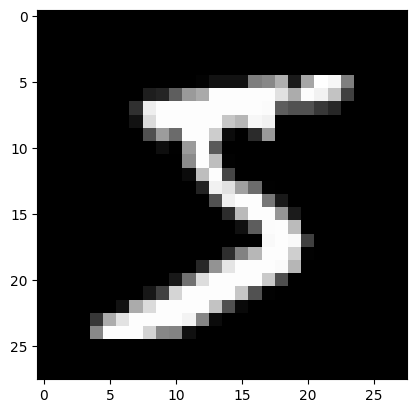

In [11]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import cv2
import numpy as np

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist. load_data()

plt.imshow(x_train[0], cmap="gray")

In [12]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [13]:
encoder_input = keras.Input(shape=(28,28,1), name="img")
x = keras.layers.Flatten()(encoder_input)
encoder_output = keras.layers.Dense(64, activation="relu")(x)

encoder = keras.Model(encoder_input, encoder_output, name="encoder")

decoder_input = keras.layers.Dense(784, activation="relu")(encoder_output)
#x = keras.layers.Dense(784, activation="relu")(decoder_input)
decoder_output = keras.layers.Reshape((28, 28, 1))(decoder_input)

opt = keras.optimizers.Adam(learning_rate=0.001)

autoencoder = keras.Model(encoder_input, decoder_output, name="autoencoder")
autoencoder.summary()
autoencoder.compile(opt, loss="mse")
autoencoder.fit(x_train, x_train, epochs=3, batch_size=32, validation_split=0.1)


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ img (InputLayer)                │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │        50,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,200 (395.31 KB)

 Trainable params: 101,200 (395.31 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0169 - val_loss: 0.0111
Epoch 2/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0107 - val_loss: 0.0103
Epoch 3/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0103 - val_loss: 0.0102


In [14]:
example = encoder.predict([x_test[1].reshape(-1, 28, 28, 1) ]) [0]
print(example)
print(example.shape)
print(32/784)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
[2.7643454  0.         1.4775532  0.763586   1.3966501  1.7909435
 0.31333452 2.836847   0.7193299  1.2546959  0.8965024  2.0223255
 2.2597852  2.1519601  0.32528004 1.0667962  3.0089393  1.9447585
 0.         1.6475892  0.73255175 1.1977468  1.035776   1.6854546
 2.5008037  0.8334162  1.3653193  1.833744   1.8747536  1.3208561
 1.4631413  2.098696   0.86188364 0.37800568 0.9911285  3.7804306
 0.6546735  2.8059082  3.0460465  1.4800366  1.594093   1.3566446
 0.8706188  0.3712348  1.1505249  2.0569308  0.23477301 1.3458863
 3.5915966  0.9252901  0.00922814 1.7735058  2.1787097  1.194662
 2.5402808  0.2303069  0.4401786  0.39324957 1.8698117  0.25854182
 1.7353418  1.2573459  0.82834184 0.52086717]
(64,)
0.04081632653061224


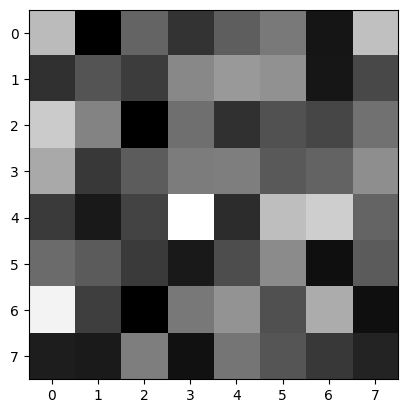

In [15]:
plt.imshow(example.reshape((8,8)), cmap="gray")

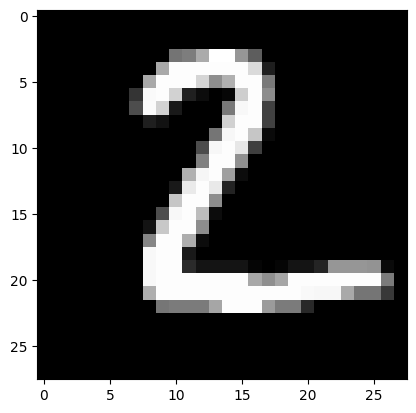

In [16]:
plt.imshow(x_test[1], cmap="gray")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


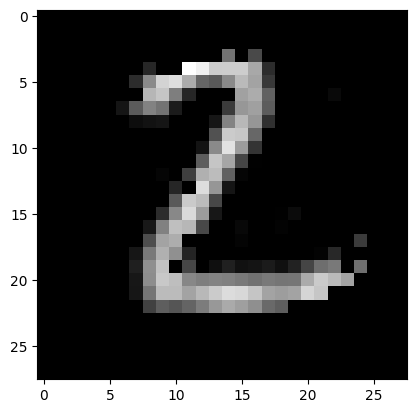

In [17]:
ae_out = autoencoder.predict([x_test[1].reshape(-1, 28, 28, 1) ] ) [0]
plt.imshow(ae_out, cmap="gray")

In [18]:
import random

def add_noise(img, random_chance=5):
    noisy = []
    for row in img:
        new_row = []
        for pix in row:
            if random.choice(range(100)) <= random_chance:
                new_val = random.uniform(0, 1)
                new_row.append(new_val)
            else:
                new_row.append(pix)
        noisy.append(new_row)
    return np.array(noisy)

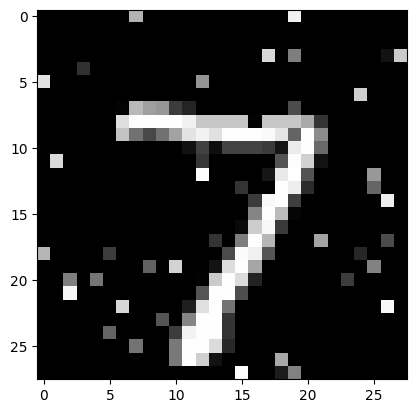

In [19]:
noisy = add_noise(x_test[0])
plt.imshow(noisy, cmap="gray")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


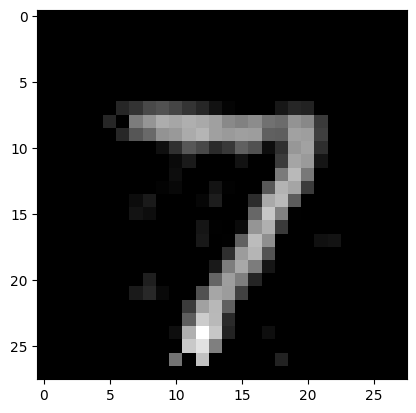

In [20]:
ae_out = autoencoder.predict([noisy. reshape(-1, 28, 28, 1) ] ) [0]

plt.imshow(ae_out, cmap="gray")
